In [ ]:
# STEP 1: Install & Import Libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch Version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

PyTorch Version: 2.9.0+cu128
GPU Available: True
Using Device: cuda


In [ ]:
# STEP 2: Load CIFAR-10 Dataset (automatic download!)
# Data augmentation for training (improves generalization)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # CIFAR-10 mean
                         (0.2023, 0.1994, 0.2010))    # CIFAR-10 std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Download and load
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True,  num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False, num_workers=2)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(f"Training samples : {len(trainset)}")
print(f"Testing samples  : {len(testset)}")
print(f"Classes          : {classes}")

100%|██████████| 170M/170M [00:12<00:00, 13.1MB/s]


Training samples : 50000
Testing samples  : 10000
Classes          : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


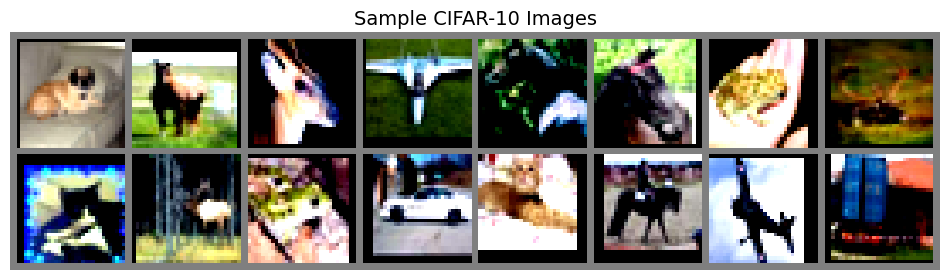

Labels: ['dog', 'horse', 'deer', 'airplane', 'horse', 'horse', 'frog', 'deer', 'cat', 'deer', 'frog', 'automobile', 'cat', 'horse', 'airplane', 'truck']


In [ ]:
# STEP 3: Visualize the Dataset
def imshow(img):
    img = img / 2 + 0.5       # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(12, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.title("Sample CIFAR-10 Images", fontsize=14)
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show first 16 images
imshow(torchvision.utils.make_grid(images[:16]))
print("Labels:", [classes[labels[i]] for i in range(16)])

In [ ]:
# STEP 4:  Baseline CNN (Simple model to beat)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
print(model)

# Count parameters (put this in your paper!)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal Parameters: {total_params:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

Total Parameters: 1,147,466


In [ ]:
# STEP 5: Training Function (reuse this for ALL your models)
def train_model(model, trainloader, testloader, epochs=20, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    history = {"train_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        train_loss = running_loss / len(trainloader)

        # Evaluate on test set
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_acc = 100. * correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        scheduler.step()

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    return history

# Train your baseline!
history = train_model(model, trainloader, testloader, epochs=20)

Epoch [01/20] | Loss: 1.5556 | Train Acc: 42.58% | Test Acc: 57.32%
Epoch [02/20] | Loss: 1.1625 | Train Acc: 58.53% | Test Acc: 67.40%
Epoch [03/20] | Loss: 1.0049 | Train Acc: 64.46% | Test Acc: 71.01%
Epoch [04/20] | Loss: 0.9161 | Train Acc: 67.92% | Test Acc: 72.25%
Epoch [05/20] | Loss: 0.8592 | Train Acc: 70.09% | Test Acc: 71.50%
Epoch [06/20] | Loss: 0.8097 | Train Acc: 71.66% | Test Acc: 75.04%
Epoch [07/20] | Loss: 0.7790 | Train Acc: 73.06% | Test Acc: 76.01%
Epoch [08/20] | Loss: 0.7459 | Train Acc: 74.12% | Test Acc: 76.33%
Epoch [09/20] | Loss: 0.7274 | Train Acc: 75.01% | Test Acc: 77.53%
Epoch [10/20] | Loss: 0.7096 | Train Acc: 75.54% | Test Acc: 76.95%
Epoch [11/20] | Loss: 0.6198 | Train Acc: 78.45% | Test Acc: 79.67%
Epoch [12/20] | Loss: 0.5933 | Train Acc: 79.61% | Test Acc: 79.82%
Epoch [13/20] | Loss: 0.5815 | Train Acc: 79.78% | Test Acc: 80.27%
Epoch [14/20] | Loss: 0.5748 | Train Acc: 80.15% | Test Acc: 80.43%
Epoch [15/20] | Loss: 0.5698 | Train Acc: 80.19%

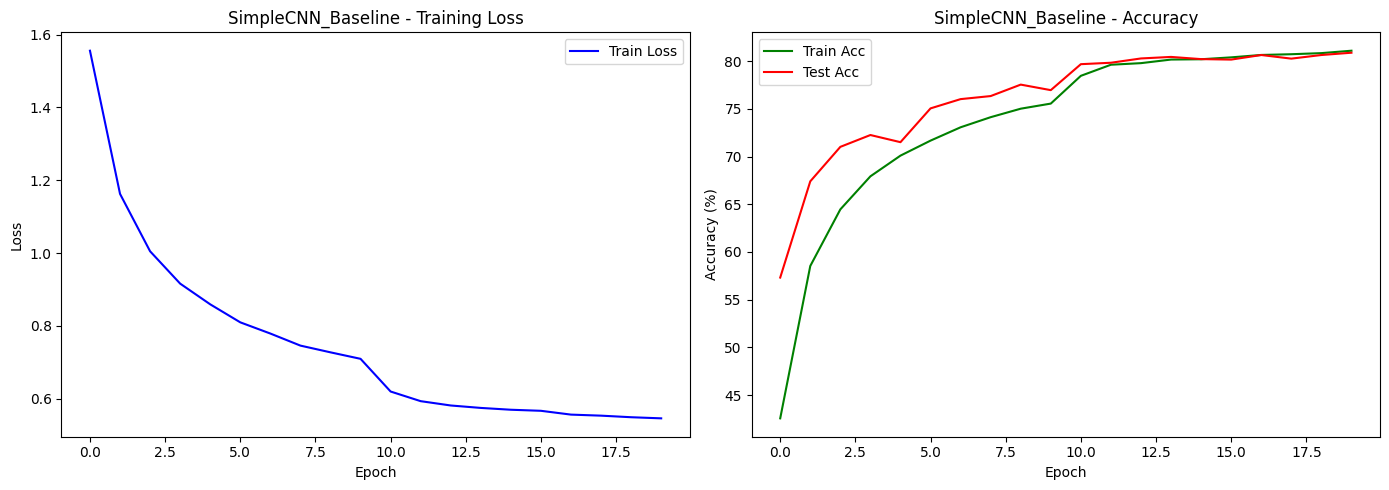

Best Test Accuracy: 80.87%


In [ ]:
# STEP 6: Plot Results
def plot_history(history, model_name="SimpleCNN"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history["train_loss"], label="Train Loss", color="blue")
    ax1.set_title(f"{model_name} - Training Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()

    ax2.plot(history["train_acc"], label="Train Acc", color="green")
    ax2.plot(history["test_acc"],  label="Test Acc",  color="red")
    ax2.set_title(f"{model_name} - Accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name}_results.png", dpi=150)  # save for your paper!
    plt.show()

plot_history(history, "SimpleCNN_Baseline")
print(f"Best Test Accuracy: {max(history['test_acc']):.2f}%")